# 06. DMFC Residual Shuffle Control

Goal:
- Test whether paddle residual adds meaningful neural encoding information beyond y_det.
- Compare observed delta R² against condition-shuffled residual controls.
- Avoid overinterpreting y_paddle as a causal neural response variable.

Main comparison:
- observed: neural ~ y_det + paddle_residual
- shuffled: neural ~ y_det + shuffled_paddle_residual

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in [PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ANALYSIS_PATH = PROCESSED_DIR / "mahler_neural_behavior_window_analysis.csv"

analysis_df = pd.read_csv(ANALYSIS_PATH)

unit_cols = [c for c in analysis_df.columns if isinstance(c, str) and c.startswith("unit_")]

print("analysis_df shape:", analysis_df.shape)
print("n unit cols:", len(unit_cols))
print("windows:", analysis_df["window"].unique())
display(analysis_df.head())

analysis_df shape: (316, 117)
n unit cols: 100
windows: <StringArray>
['pre_occ', 'early_occ', 'late_occ', 'full_occ']
Length: 4, dtype: str


,condition_i,window,unit_000,unit_001,unit_002,unit_003,unit_004,unit_005,unit_006,unit_007,unit_008,unit_009,unit_010,unit_011,unit_012,unit_013,unit_014,unit_015,unit_016,unit_017,unit_018,unit_019,unit_020,unit_021,unit_022,unit_023,unit_024,unit_025,unit_026,unit_027,unit_028,unit_029,unit_030,unit_031,unit_032,unit_033,unit_034,unit_035,unit_036,unit_037,unit_038,unit_039,unit_040,unit_041,unit_042,unit_043,unit_044,unit_045,unit_046,unit_047,unit_048,unit_049,unit_050,unit_051,unit_052,unit_053,unit_054,unit_055,unit_056,unit_057,unit_058,unit_059,unit_060,unit_061,unit_062,unit_063,unit_064,unit_065,unit_066,unit_067,unit_068,unit_069,unit_070,unit_071,unit_072,unit_073,unit_074,unit_075,unit_076,unit_077,unit_078,unit_079,unit_080,unit_081,unit_082,unit_083,unit_084,unit_085,unit_086,unit_087,unit_088,unit_089,unit_090,unit_091,unit_092,unit_093,unit_094,unit_095,unit_096,unit_097,unit_098,unit_099,y_det,y_true,y_paddle,y_occ,vy_occ,abs_vy_occ,n_steps,n_bounce,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc
0,0,pre_occ,-0.590960,1.379389,0.452114,0.537548,1.522249,-0.845046,2.053754,3.514321,1.697143,2.149586,1.698270,-1.102545,0.703921,-1.271515,-0.474848,-0.388881,0.780072,-0.779988,-2.119404,-1.273460,-0.998197,1.117492,-0.555672,1.296359,-1.555603,-0.746918,-2.046147,0.234285,-1.294374,-0.088340,-0.510056,0.663737,-2.616444,0.710196,-0.373478,-0.741576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
1,0,early_occ,-1.761323,0.703368,0.012818,0.263659,2.038235,-0.463798,3.206495,1.438544,1.285506,2.240759,1.433952,-2.121635,1.021560,-0.667143,-1.678263,-0.785434,1.103000,-0.775119,-2.028484,-1.319110,-0.473471,0.061597,-0.968218,1.620691,-1.107949,-2.157704,-2.545793,0.926265,-1.978958,0.311227,-0.906618,1.396752,-2.399197,1.016280,0.208842,0.373721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
2,0,late_occ,-2.529047,0.405583,0.375527,0.746150,1.569107,-0.512101,1.947588,1.768042,0.911661,1.733232,-0.286895,-2.597691,0.091238,-0.954154,-2.467268,-1.589378,0.313071,-1.654406,-3.050250,-2.382095,-1.104586,-0.694091,-1.492470,0.149023,-2.130489,-1.784460,-2.654677,0.089028,-1.202022,-0.381539,-1.281830,0.054391,-2.541745,0.237296,-0.538895,-0.089518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
3,0,full_occ,-2.042917,0.574913,0.263535,0.597847,1.957729,-0.368715,2.752251,1.709203,1.200211,2.067702,0.820758,-2.194163,0.802000,-0.663379,-1.848456,-0.955042,0.913092,-1.056834,-2.308680,-1.638676,-0.668167,-0.124003,-1.025869,1.175345,-1.373847,-1.873472,-2.381988,0.716753,-1.594069,0.134549,-1.081084,0.886147,-2.342833,0.531793,0.015582,0.216616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.6

In [2]:
def make_kfold_indices(n, n_splits=5, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, n_splits)
    
    splits = []
    for i in range(n_splits):
        test_idx = folds[i]
        train_idx = np.setdiff1d(idx, test_idx)
        splits.append((train_idx, test_idx))
    
    return splits


def standardize_train_test(X_train, X_test, eps=1e-8):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    
    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)
    std = np.where(std < eps, 1.0, std)
    
    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std
    
    X_train_z = np.where(np.isfinite(X_train_z), X_train_z, 0.0)
    X_test_z = np.where(np.isfinite(X_test_z), X_test_z, 0.0)
    
    return X_train_z, X_test_z


def add_intercept(X):
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(len(X)), X])


def fit_ridge(X, Y, alpha=1.0):
    I = np.eye(X.shape[1])
    return np.linalg.solve(X.T @ X + alpha * I, X.T @ Y)


def prepare_window_data(df, window, unit_cols, min_unit_finite=0.2):
    sub = df[df["window"] == window].copy().reset_index(drop=True)
    
    Y_raw = sub[unit_cols].to_numpy(dtype=float)
    
    finite_ratio = np.isfinite(Y_raw).mean(axis=0)
    unit_std = np.nanstd(Y_raw, axis=0)
    
    keep_units = (
        (finite_ratio >= min_unit_finite) &
        np.isfinite(unit_std) &
        (unit_std > 1e-8)
    )
    
    if keep_units.sum() < 3:
        keep_units = (
            (finite_ratio >= 0.05) &
            np.isfinite(unit_std) &
            (unit_std > 1e-8)
        )
    
    kept_unit_cols = [c for c, k in zip(unit_cols, keep_units) if k]
    Y = Y_raw[:, keep_units]
    
    return sub, Y, kept_unit_cols

In [3]:
def evaluate_encoding_for_window(
    df,
    window,
    features,
    unit_cols,
    n_splits=5,
    seed=42,
    alpha=1.0,
    min_unit_finite=0.2,
):
    sub, Y_raw, kept_units = prepare_window_data(
        df,
        window,
        unit_cols,
        min_unit_finite=min_unit_finite,
    )
    
    X_raw = sub[features].to_numpy(dtype=float)
    
    valid_x = np.isfinite(X_raw).any(axis=1)
    sub = sub.loc[valid_x].reset_index(drop=True)
    X_raw = X_raw[valid_x]
    Y_raw = Y_raw[valid_x]
    
    splits = make_kfold_indices(len(sub), n_splits=n_splits, seed=seed)
    
    all_sse = 0.0
    all_sst = 0.0
    fold_rows = []
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]
        
        Y_train_raw = Y_raw[train_idx]
        Y_test_raw = Y_raw[test_idx]
        
        X_train_z, X_test_z = standardize_train_test(X_train_raw, X_test_raw)
        X_train_design = add_intercept(X_train_z)
        X_test_design = add_intercept(X_test_z)
        
        y_mean = np.nanmean(Y_train_raw, axis=0, keepdims=True)
        y_std = np.nanstd(Y_train_raw, axis=0, keepdims=True)
        y_std = np.where(y_std < 1e-8, 1.0, y_std)
        
        Y_train_z = (Y_train_raw - y_mean) / y_std
        Y_test_z = (Y_test_raw - y_mean) / y_std
        
        Y_train_z_fit = np.where(np.isfinite(Y_train_z), Y_train_z, 0.0)
        
        beta = fit_ridge(X_train_design, Y_train_z_fit, alpha=alpha)
        Y_pred_z = X_test_design @ beta
        
        mask = np.isfinite(Y_test_z)
        
        if mask.sum() > 0:
            residual = Y_test_z[mask] - Y_pred_z[mask]
            sse = np.sum(residual ** 2)
            sst = np.sum(Y_test_z[mask] ** 2)
            fold_r2 = 1.0 - sse / sst if sst > 0 else np.nan
            
            all_sse += sse
            all_sst += sst
        else:
            sse = np.nan
            sst = np.nan
            fold_r2 = np.nan
        
        fold_rows.append({
            "window": window,
            "fold": fold,
            "features": ",".join(features),
            "fold_population_r2": fold_r2,
            "sse": sse,
            "sst": sst,
            "n_units": len(kept_units),
        })
    
    pop_r2 = 1.0 - all_sse / all_sst if all_sst > 0 else np.nan
    
    return pd.DataFrame(fold_rows), pop_r2

In [4]:
cond_df = (
    analysis_df[["condition_i", "y_det", "y_paddle"]]
    .drop_duplicates("condition_i")
    .copy()
)

valid = np.isfinite(cond_df["y_det"]) & np.isfinite(cond_df["y_paddle"])

coef = np.polyfit(
    cond_df.loc[valid, "y_det"],
    cond_df.loc[valid, "y_paddle"],
    deg=1,
)

gain_global = coef[0]
intercept_global = coef[1]

cond_df["y_paddle_pred_from_y_det"] = (
    gain_global * cond_df["y_det"] + intercept_global
)

cond_df["paddle_residual_from_y_det"] = (
    cond_df["y_paddle"] - cond_df["y_paddle_pred_from_y_det"]
)

print("global gain:", gain_global)
print("global intercept:", intercept_global)
display(cond_df.head())

analysis_df = analysis_df.drop(
    columns=["y_paddle_pred_from_y_det", "paddle_residual_from_y_det"],
    errors="ignore",
)

analysis_df = analysis_df.merge(
    cond_df[[
        "condition_i",
        "y_paddle_pred_from_y_det",
        "paddle_residual_from_y_det",
    ]],
    on="condition_i",
    how="left",
)

global gain: 0.8736645456633193
global intercept: -0.21198693774335028


,condition_i,y_det,y_paddle,y_paddle_pred_from_y_det,paddle_residual_from_y_det
0,0,-0.271351,-0.688933,-0.449056,-0.239876
4,1,-5.085588,-3.723874,-4.655085,0.931211
8,2,-6.007187,-5.745208,-5.460253,-0.284955
12,3,-9.952948,-7.246475,-8.907524,1.661049
16,4,5.580770,5.144827,4.663734,0.481093


In [5]:
observed_rows = []

for win in analysis_df["window"].unique():
    _, r2_base = evaluate_encoding_for_window(
        df=analysis_df,
        window=win,
        features=["y_det"],
        unit_cols=unit_cols,
        n_splits=5,
        seed=42,
        alpha=1.0,
    )
    
    _, r2_resid = evaluate_encoding_for_window(
        df=analysis_df,
        window=win,
        features=["y_det", "paddle_residual_from_y_det"],
        unit_cols=unit_cols,
        n_splits=5,
        seed=42,
        alpha=1.0,
    )
    
    observed_rows.append({
        "window": win,
        "base_r2": r2_base,
        "residual_model_r2": r2_resid,
        "observed_delta_r2": r2_resid - r2_base,
    })

observed_df = pd.DataFrame(observed_rows)
display(observed_df)

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_im

,window,base_r2,residual_model_r2,observed_delta_r2
0,pre_occ,0.458412,0.484489,0.026078
1,early_occ,0.442656,0.463417,0.020761
2,late_occ,0.424147,0.446009,0.021862
3,full_occ,0.448578,0.477865,0.029287


In [6]:
def run_residual_shuffle_test(
    analysis_df,
    unit_cols,
    n_shuffle=200,
    seed=123,
):
    rng = np.random.default_rng(seed)
    
    # Observed
    observed_rows = []
    
    for win in analysis_df["window"].unique():
        _, r2_base = evaluate_encoding_for_window(
            df=analysis_df,
            window=win,
            features=["y_det"],
            unit_cols=unit_cols,
            n_splits=5,
            seed=42,
            alpha=1.0,
        )
        
        _, r2_obs = evaluate_encoding_for_window(
            df=analysis_df,
            window=win,
            features=["y_det", "paddle_residual_from_y_det"],
            unit_cols=unit_cols,
            n_splits=5,
            seed=42,
            alpha=1.0,
        )
        
        observed_rows.append({
            "window": win,
            "base_r2": r2_base,
            "observed_r2": r2_obs,
            "observed_delta_r2": r2_obs - r2_base,
        })
    
    observed_df = pd.DataFrame(observed_rows)
    
    # Condition-level residual table
    cond_resid = (
        analysis_df[["condition_i", "paddle_residual_from_y_det"]]
        .drop_duplicates("condition_i")
        .copy()
        .sort_values("condition_i")
        .reset_index(drop=True)
    )
    
    shuffle_rows = []
    
    for s in range(n_shuffle):
        shuffled_values = cond_resid["paddle_residual_from_y_det"].values.copy()
        rng.shuffle(shuffled_values)
        
        shuf_map = cond_resid[["condition_i"]].copy()
        shuf_map["paddle_residual_shuffled"] = shuffled_values
        
        shuf_df = analysis_df.drop(
            columns=["paddle_residual_shuffled"],
            errors="ignore",
        ).merge(
            shuf_map,
            on="condition_i",
            how="left",
        )
        
        for win in shuf_df["window"].unique():
            _, r2_base = evaluate_encoding_for_window(
                df=shuf_df,
                window=win,
                features=["y_det"],
                unit_cols=unit_cols,
                n_splits=5,
                seed=42,
                alpha=1.0,
            )
            
            _, r2_shuf = evaluate_encoding_for_window(
                df=shuf_df,
                window=win,
                features=["y_det", "paddle_residual_shuffled"],
                unit_cols=unit_cols,
                n_splits=5,
                seed=42,
                alpha=1.0,
            )
            
            shuffle_rows.append({
                "shuffle": s,
                "window": win,
                "shuffled_r2": r2_shuf,
                "shuffled_delta_r2": r2_shuf - r2_base,
            })
    
    shuffle_df = pd.DataFrame(shuffle_rows)
    
    # Summary
    summary_rows = []
    
    for _, obs in observed_df.iterrows():
        win = obs["window"]
        obs_delta = obs["observed_delta_r2"]
        shuf = shuffle_df.loc[
            shuffle_df["window"] == win,
            "shuffled_delta_r2",
        ].values
        
        p_empirical = (np.sum(shuf >= obs_delta) + 1) / (len(shuf) + 1)
        
        summary_rows.append({
            "window": win,
            "base_r2": obs["base_r2"],
            "observed_r2": obs["observed_r2"],
            "observed_delta_r2": obs_delta,
            "shuffle_mean_delta": np.mean(shuf),
            "shuffle_std_delta": np.std(shuf, ddof=1),
            "shuffle_p95": np.percentile(shuf, 95),
            "shuffle_p99": np.percentile(shuf, 99),
            "empirical_p": p_empirical,
        })
    
    summary_df = pd.DataFrame(summary_rows)
    
    return summary_df, shuffle_df, observed_df


shuffle_summary, shuffle_dist, observed_df = run_residual_shuffle_test(
    analysis_df=analysis_df,
    unit_cols=unit_cols,
    n_shuffle=200,
    seed=123,
)

display(shuffle_summary)

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_im

,window,base_r2,observed_r2,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p
0,pre_occ,0.458412,0.484489,0.026078,-0.008774,0.005189,-0.000572,0.002383,0.004975
1,early_occ,0.442656,0.463417,0.020761,-0.008937,0.005035,-0.000884,0.001955,0.004975
2,late_occ,0.424147,0.446009,0.021862,-0.009375,0.005474,-0.000557,0.003534,0.004975
3,full_occ,0.448578,0.477865,0.029287,-0.009119,0.005020,-0.001038,0.002560,0.004975


# Plot

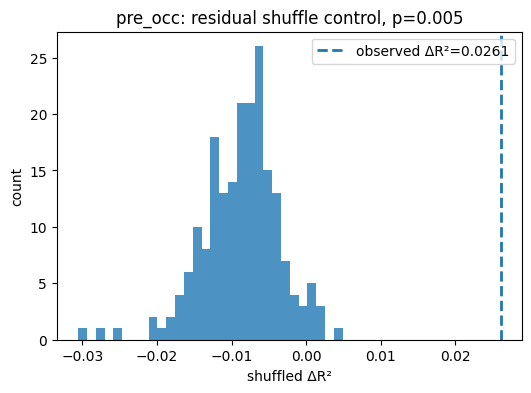

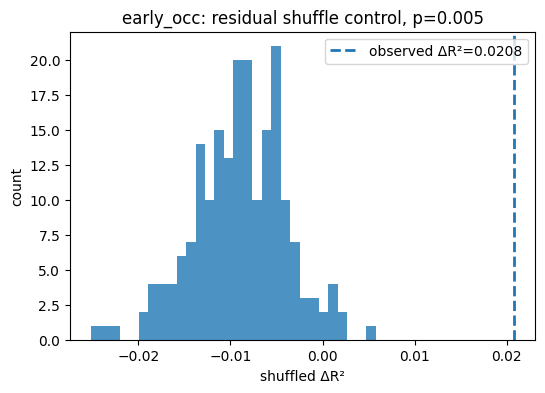

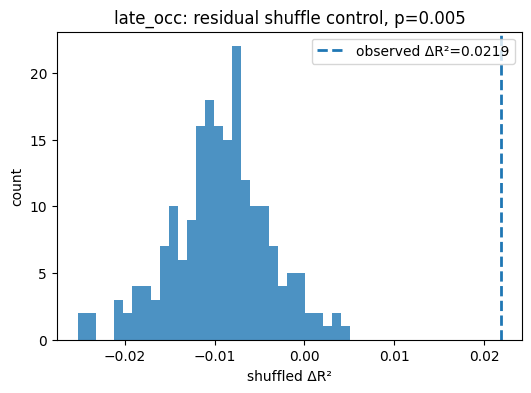

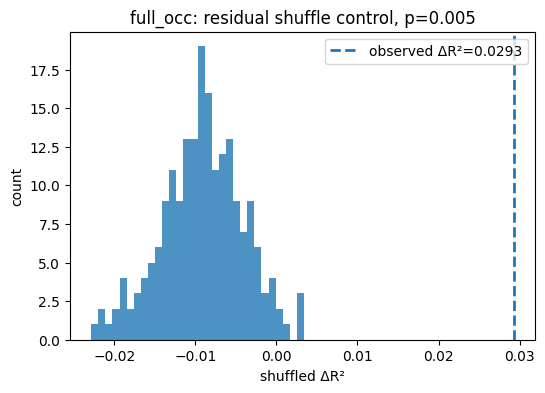

In [7]:
for win in shuffle_summary["window"]:
    shuf = shuffle_dist.loc[
        shuffle_dist["window"] == win,
        "shuffled_delta_r2",
    ]
    
    obs = shuffle_summary.loc[
        shuffle_summary["window"] == win,
        "observed_delta_r2",
    ].iloc[0]
    
    p = shuffle_summary.loc[
        shuffle_summary["window"] == win,
        "empirical_p",
    ].iloc[0]
    
    plt.figure(figsize=(6, 4))
    plt.hist(shuf, bins=30, alpha=0.8)
    plt.axvline(obs, linestyle="--", linewidth=2, label=f"observed ΔR²={obs:.4f}")
    plt.xlabel("shuffled ΔR²")
    plt.ylabel("count")
    plt.title(f"{win}: residual shuffle control, p={p:.3f}")
    plt.legend()
    plt.show()

In [8]:
SHUFFLE_SUMMARY_PATH = PROCESSED_DIR / "dmfc_paddle_residual_shuffle_summary_mahler.csv"
SHUFFLE_DIST_PATH = PROCESSED_DIR / "dmfc_paddle_residual_shuffle_dist_mahler.csv"
OBSERVED_PATH = PROCESSED_DIR / "dmfc_paddle_residual_observed_mahler.csv"

shuffle_summary.to_csv(SHUFFLE_SUMMARY_PATH, index=False)
shuffle_dist.to_csv(SHUFFLE_DIST_PATH, index=False)
observed_df.to_csv(OBSERVED_PATH, index=False)

print("Saved:", SHUFFLE_SUMMARY_PATH)
print("Saved:", SHUFFLE_DIST_PATH)
print("Saved:", OBSERVED_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_paddle_residual_shuffle_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_paddle_residual_shuffle_dist_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_paddle_residual_observed_mahler.csv
